# B.Tech. Project: Neural Network Based KKT Solver
## Pyomo Modeling, KKT Extraction, and Neural Network Solver Pipeline

**Students Name:** Sahitya Rankawat, Manav Gupta, Jeet Anand  
**Supervisor:** Prof. Kartikey Sharma  
**Department:** Mechanical Engineering  

---

### Overview:
1. **Part 1 (Baseline Solver Pipeline):** Formulate the optimization problem in Pyomo, solve it directly using the **HiGHS** solver, and visualize the 2D solution.
2. **Part 2 (KKT Extraction Pipeline):** Automatically extract the algebraic **Karush-Kuhn-Tucker (KKT)** equations from Pyomo and verify them using the solver output.
3. **Part 3 (Benchmark File Input & First Iteration Neural Network):** Load a benchmark problem file using the **HiGHS file reader**, and run our **first iteration of an Artificial Neural Network (ANN)** trained on the KKT loss to inspect its output predictions.


---
## Part 1: Modeling & Solving the Main Problem in HiGHS
We define our optimization problem in **Pyomo** and solve it directly using **HiGHS** (a fast, open-source optimization solver).


### Setup & Imports
If running on **Google Colab**, running the cell below installs Pyomo, HiGHS, and PyTorch.


In [1]:
# Install Pyomo, HiGHS solver, and PyTorch
!pip install -q pyomo highspy torch numpy matplotlib


In [2]:
# Import libraries
import os
import numpy as np
import matplotlib.pyplot as plt
import pyomo.environ as pyo
from pyomo.repn import generate_standard_repn
import highspy
import torch
import torch.nn as nn
import time

print("All libraries imported successfully!")


All libraries imported successfully!


### Formulating the Optimization Problem in Pyomo

Let's model a standard 2-variable Linear Programming problem:
- **Goal:** Maximize $3x_1 + 2x_2$  
  *(In standard minimization form, this is equivalent to minimizing $-3x_1 - 2x_2$)*
- **Constraint 1:** $2x_1 + x_2 \le 10$
- **Constraint 2:** $x_1 + 3x_2 \le 12$
- **Bounds:** $x_1 \ge 0, \quad x_2 \ge 0$


In [3]:
# Initialize the Pyomo Model
model = pyo.ConcreteModel(name="2D_Sample_LP")

# Define the decision variables (x1 >= 0 and x2 >= 0)
model.x1 = pyo.Var(domain=pyo.NonNegativeReals, name="x1")
model.x2 = pyo.Var(domain=pyo.NonNegativeReals, name="x2")

# Define the Objective function (Minimize -3*x1 - 2*x2)
model.obj = pyo.Objective(expr=-3.0 * model.x1 - 2.0 * model.x2, sense=pyo.minimize)

# Define the Constraints
model.c1 = pyo.Constraint(expr=2.0 * model.x1 + 1.0 * model.x2 <= 10.0)
model.c2 = pyo.Constraint(expr=1.0 * model.x1 + 3.0 * model.x2 <= 12.0)

print("Pyomo model created successfully!")


Pyomo model created successfully!


In [4]:
# Inspect the model structure
model.pprint()


2 Var Declarations
    x1 : Size=1, Index=None
        Key  : Lower : Value : Upper : Fixed : Stale : Domain
        None :     0 :  None :  None : False :  True : NonNegativeReals
    x2 : Size=1, Index=None
        Key  : Lower : Value : Upper : Fixed : Stale : Domain
        None :     0 :  None :  None : False :  True : NonNegativeReals

1 Objective Declarations
    obj : Size=1, Index=None, Active=True
        Key  : Active : Sense    : Expression
        None :   True : minimize : -3.0*x1 - 2.0*x2

2 Constraint Declarations
    c1 : Size=1, Index=None, Active=True
        Key  : Lower : Body        : Upper : Active
        None :  -Inf : 2.0*x1 + x2 :  10.0 :   True
    c2 : Size=1, Index=None, Active=True
        Key  : Lower : Body        : Upper : Active
        None :  -Inf : x1 + 3.0*x2 :  12.0 :   True

5 Declarations: x1 x2 obj c1 c2


### Solving the Main Problem Directly with HiGHS

We send our Pyomo model to **HiGHS** and ask Pyomo to import:
- `model.dual`: Lagrange multipliers ($\lambda$) for constraints
- `model.rc`: Reduced costs for variable bounds


In [5]:
# Enable dual and reduced cost collection
model.dual = pyo.Suffix(direction=pyo.Suffix.IMPORT)
model.rc   = pyo.Suffix(direction=pyo.Suffix.IMPORT)

# Solve the model directly using HiGHS
solver = pyo.SolverFactory('appsi_highs')
results = solver.solve(model)

# Extract optimal primal variables
x1_val = pyo.value(model.x1)
x2_val = pyo.value(model.x2)
opt_obj = pyo.value(model.obj)

print("=== HiGHS Direct Solver Results ===")
print(f"Solver Status: {results.solver.termination_condition}")
print(f"Optimal x1* = {x1_val:.4f}")
print(f"Optimal x2* = {x2_val:.4f}")
print(f"Optimal Objective (Min): {opt_obj:.4f}  (Original Max = {-opt_obj:.4f})")
print(f"Constraint c1 dual value: {model.dual[model.c1]}")
print(f"Constraint c2 dual value: {model.dual[model.c2]}")


=== HiGHS Direct Solver Results ===
Solver Status: optimal
Optimal x1* = 3.6000
Optimal x2* = 2.8000
Optimal Objective (Min): -16.4000  (Original Max = 16.4000)
Constraint c1 dual value: -1.4
Constraint c2 dual value: -0.20000000000000018


### Visualizing the Feasible Region & Optimal Solution
Let's plot the constraint lines, shade the feasible region, and show the optimal point found by HiGHS:


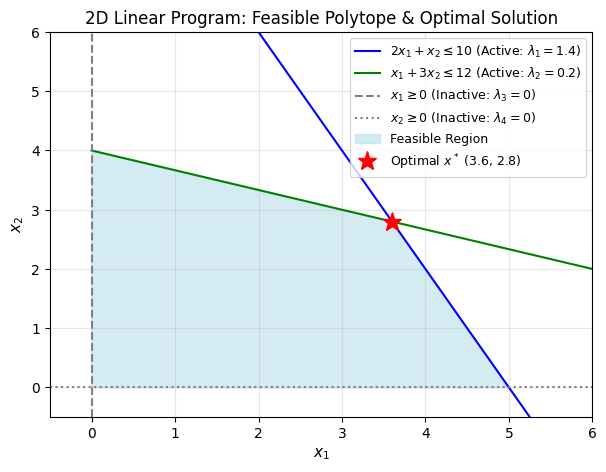

In [6]:
# Plot constraints and the optimal point
x1_plot = np.linspace(0, 6, 400)
line1 = 10 - 2 * x1_plot
line2 = (12 - x1_plot) / 3.0

plt.figure(figsize=(7, 5))
plt.plot(x1_plot, line1, 'b-', label=r'$2x_1 + x_2 \leq 10$ (Active: $\lambda_1 = 1.4$)')
plt.plot(x1_plot, line2, 'g-', label=r'$x_1 + 3x_2 \leq 12$ (Active: $\lambda_2 = 0.2$)')
plt.axvline(0, color='gray', linestyle='--', label=r'$x_1 \geq 0$ (Inactive: $\lambda_3 = 0$)')
plt.axhline(0, color='gray', linestyle=':', label=r'$x_2 \geq 0$ (Inactive: $\lambda_4 = 0$)')

# Shade feasible region
y_top = np.minimum(np.maximum(0, line1), np.maximum(0, line2))
plt.fill_between(x1_plot, 0, y_top, where=(x1_plot <= 5), color='lightblue', alpha=0.5, label='Feasible Region')

# Plot optimal point
plt.plot(x1_val, x2_val, 'r*', markersize=14, label=f'Optimal Point ({x1_val:.2f}, {x2_val:.2f})')

plt.xlim(-0.5, 6)
plt.ylim(-0.5, 6)
plt.xlabel('$x_1$', fontsize=11)
plt.ylabel('$x_2$', fontsize=11)
plt.title('2D Linear Program: Feasible Polytope & Optimal Solution', fontsize=12)
plt.legend(loc='upper right', fontsize=9)
plt.grid(True, alpha=0.3)
plt.show()


---
## Part 2: The KKT Extraction & Verification Pipeline
Now that we have verified that the main problem works in HiGHS, we move to the core: how do we turn this optimization problem into a system of algebraic equations using the **Karush-Kuhn-Tucker (KKT)** conditions so a Neural Network can learn to solve it?


### What are the KKT Optimality Conditions?

For any optimization problem $\min c^T x \text{ s.t. } G x \le h$, the KKT conditions give 4 necessary and sufficient rules for global optimality:

1. **Stationarity:** The forces from the objective and the active constraints balance out to zero:
   $$c + G^T \lambda = 0$$
2. **Primal Feasibility:** The solution satisfies all constraints:
   $$G x - h \le 0$$
3. **Dual Feasibility:** All constraint multipliers $\lambda$ must be non-negative:
   $$\lambda \ge 0$$
4. **Complementary Slackness:** Inactive constraints have a multiplier of zero:
   $$\lambda_i \cdot (G x - h)_i = 0$$


### Automatically Extracting KKT Equations from Pyomo

We write `extract_kkt_system()` to read our Pyomo model and extract the canonical matrices:
- Cost vector $c$
- Constraint matrix $G$ and RHS vector $h$
- Bound constraints (e.g., $x_1 \ge 0 \implies -x_1 \le 0$)


In [7]:
def extract_kkt_system(model):
    # Collect active variables
    vars_list = list(model.component_data_objects(pyo.Var, active=True))
    var_names = [v.name for v in vars_list]
    var_map = {id(v): i for i, v in enumerate(vars_list)}
    n_vars = len(vars_list)
    
    # Extract cost vector c from objective
    obj = next(model.component_data_objects(pyo.Objective, active=True))
    repn_obj = generate_standard_repn(obj.expr)
    c = np.zeros(n_vars)
    if repn_obj.linear_vars:
        for v, coef in zip(repn_obj.linear_vars, repn_obj.linear_coefs):
            c[var_map[id(v)]] += float(coef)
    if obj.sense == pyo.maximize:
        c = -c  # convert max to min
        
    # Extract constraints G x <= h
    G_rows = []
    h_vals = []
    con_names = []
    
    for con in model.component_data_objects(pyo.Constraint, active=True):
        repn = generate_standard_repn(con.body)
        row = np.zeros(n_vars)
        if repn.linear_vars:
            for v, coef in zip(repn.linear_vars, repn.linear_coefs):
                row[var_map[id(v)]] += float(coef)
        const = float(repn.constant) if repn.constant is not None else 0.0
        
        # Upper bound constraint: body <= upper
        if con.upper is not None:
            G_rows.append(row)
            h_vals.append(float(con.upper) - const)
            con_names.append(f"{con.name} (upper)")
            
        # Lower bound constraint: body >= lower => -body <= -lower
        if con.lower is not None:
            G_rows.append(-row)
            h_vals.append(const - float(con.lower))
            con_names.append(f"{con.name} (lower)")
            
    # Include variable lower bounds: x_i >= lb => -x_i <= -lb
    for i, v in enumerate(vars_list):
        if v.lb is not None and not np.isneginf(v.lb):
            row = np.zeros(n_vars)
            row[i] = -1.0
            G_rows.append(row)
            h_vals.append(-float(v.lb))
            con_names.append(f"bound: {v.name} >= {v.lb}")
            
    G = np.array(G_rows, dtype=np.float64)
    h = np.array(h_vals, dtype=np.float64)
    
    return {
        "var_names": var_names,
        "con_names": con_names,
        "c": c,
        "G": G,
        "h": h
    }

print("extract_kkt_system function is ready!")


extract_kkt_system function is ready!


Let's extract and view the algebraic equations for our 2D model:


In [8]:
# Extract components from our 2D model
kkt_data = extract_kkt_system(model)

print("Variables:", kkt_data["var_names"])
print("Cost vector c:", kkt_data["c"])
print("Constraint Matrix G:")
print(kkt_data["G"])
print("Right-Hand Side h:", kkt_data["h"])
print("Constraint Names:", kkt_data["con_names"])


Variables: ['x1', 'x2']
Cost vector c: [-3. -2.]
Constraint Matrix G:
[[ 2.  1.]
 [ 1.  3.]
 [-1.  0.]
 [ 0. -1.]]
Right-Hand Side h: [10. 12. -0. -0.]
Constraint Names: ['c1 (upper)', 'c2 (upper)', 'bound: x1 >= 0', 'bound: x2 >= 0']


In [9]:
# Display the algebraic stationarity equations
print("=== Extracted KKT Stationarity Equations ===")
for i, name in enumerate(kkt_data["var_names"]):
    equation_parts = [f"{kkt_data['c'][i]:+.2f}"]
    for k in range(len(kkt_data['h'])):
        if kkt_data['G'][k, i] != 0:
            equation_parts.append(f"{kkt_data['G'][k, i]:+.2f}*lambda_{k+1}")
    print(f"dL / d{name} :  {' '.join(equation_parts)}  =  0")


=== Extracted KKT Stationarity Equations ===
dL / dx1 :  -3.00 +2.00*lambda_1 +1.00*lambda_2 -1.00*lambda_3  =  0
dL / dx2 :  -2.00 +1.00*lambda_1 +3.00*lambda_2 -1.00*lambda_4  =  0


### Verifying the KKT Equations with HiGHS Solution

We now plug the HiGHS primal solution ($x^*$) and dual multipliers ($\lambda^*$) into our extracted equations to prove they are 100% mathematically consistent:


In [10]:
# Build complete primal (x*) and dual (lambda*) vectors
x_star = np.array([x1_val, x2_val])

# Note: In Pyomo minimization, dual on <= is negative, so lambda = -dual
lambda_1 = max(0.0, -float(model.dual[model.c1]))
lambda_2 = max(0.0, -float(model.dual[model.c2]))
lambda_3 = max(0.0, float(model.rc[model.x1]))  # Bound x1 >= 0
lambda_4 = max(0.0, float(model.rc[model.x2]))  # Bound x2 >= 0

lambda_star = np.array([lambda_1, lambda_2, lambda_3, lambda_4])

print("Optimal x* vector:     ", x_star)
print("Optimal lambda* vector:", lambda_star)


Optimal x* vector:      [3.6 2.8]
Optimal lambda* vector: [1.4 0.2 0.  0. ]


In [11]:
# Calculate the 4 KKT condition residuals
c = kkt_data["c"]
G = kkt_data["G"]
h = kkt_data["h"]

# 1. Stationarity: c + G^T * lambda = 0
res_stationarity = c + G.T @ lambda_star

# 2. Primal Feasibility: max(0, G*x - h) = 0
slack = G @ x_star - h
res_primal = np.maximum(0.0, slack)

# 3. Dual Feasibility: max(0, -lambda) = 0
res_dual = np.maximum(0.0, -lambda_star)

# 4. Complementary Slackness: lambda * (G*x - h) = 0
res_slackness = lambda_star * slack

print("=== KKT RESIDUAL VERIFICATION ===")
print(f"1. Stationarity Error ||c + G^T lambda||:     {np.linalg.norm(res_stationarity):.6e}")
print(f"2. Primal Infeasibility Error:               {np.linalg.norm(res_primal):.6e}")
print(f"3. Dual Infeasibility Error:                 {np.linalg.norm(res_dual):.6e}")
print(f"4. Complementary Slackness Error:            {np.linalg.norm(res_slackness):.6e}")
print("-------------------------------------------------")
total_kkt_error = (np.linalg.norm(res_stationarity) + 
                   np.linalg.norm(res_primal) + 
                   np.linalg.norm(res_dual) + 
                   np.linalg.norm(res_slackness))
print(f"TOTAL KKT ERROR: {total_kkt_error:.6e}")


=== KKT RESIDUAL VERIFICATION ===
1. Stationarity Error ||c + G^T lambda||:     4.440892e-16
2. Primal Infeasibility Error:               0.000000e+00
3. Dual Infeasibility Error:                 0.000000e+00
4. Complementary Slackness Error:            0.000000e+00
-------------------------------------------------
TOTAL KKT ERROR: 4.440892e-16


---
## Part 3: HiGHS Benchmark File Input & First NN Iteration

Here we connect the two latest milestones of our project:
1. **HiGHS File Ingestion:** We use HiGHS (`highspy`) to load standard benchmark files (`.mps` / `.lp`) and extract their canonical matrices.
2. **First Neural Network Iteration:** We build a simple **Artificial Neural Network (ANN)** trained with the **KKT Loss Function** to observe its output predictions for optimal primal and dual variables.


### Step 1: Loading a Benchmark File using HiGHS Reader

We use HiGHS's fast C++ reader to load a benchmark problem (from `BTP/input/tiny_test.mps`), solve it, and extract the ground-truth optimal primal and dual solutions.


In [12]:
# Path to benchmark problem
benchmark_file = os.path.join("benchmarks", "input", "tiny_test.mps")

# Load and solve directly with highspy
h_reader = highspy.Highs()
h_reader.setOptionValue("output_flag", False)
read_status = h_reader.readModel(benchmark_file)
h_reader.run()

# Extract solution from HiGHS
solution = h_reader.getSolution()
highs_primal = np.array(solution.col_value)
highs_dual_con = np.array(solution.row_dual)

print(f"Successfully loaded '{benchmark_file}' via HiGHS reader!")
print(f"HiGHS Ground-Truth Primal x*: {highs_primal}")
print(f"HiGHS Constraint Duals:      {highs_dual_con}")


Successfully loaded 'BTP/input/tiny_test.mps' via HiGHS reader!
HiGHS Ground-Truth Primal x*: [3.6 2.8]
HiGHS Constraint Duals:      [-1.4 -0.2]


### Step 2: First Architecture Iteration — Simple ANN (`KKTSolverANN`)

We build our first iteration of an **Artificial Neural Network**:
- **Input:** Problem parameters $\theta = [c_1, c_2, h_1, h_2]$.
- **Primal Output Head:** Decision variables $\hat{x} \in \mathbb{R}^2$.
- **Dual Output Head:** Multipliers $\hat{\lambda} \in \mathbb{R}_+^4$ with a `ReLU` layer to guarantee Dual Feasibility ($\hat{\lambda} \ge 0$).


In [13]:
# Define First Iteration Artificial Neural Network
class KKTSolverANN(nn.Module):
    def __init__(self):
        super().__init__()
        # Simple 2-layer hidden backbone
        self.backbone = nn.Sequential(
            nn.Linear(4, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU()
        )
        # Primal Head (x_hat)
        self.primal_head = nn.Linear(64, 2)
        
        # Dual Head (lambda_hat with ReLU to enforce lambda >= 0)
        self.dual_head = nn.Sequential(
            nn.Linear(64, 4),
            nn.ReLU()
        )
        
    def forward(self, theta):
        feat = self.backbone(theta)
        x_hat = self.primal_head(feat)
        lambda_hat = self.dual_head(feat)
        return x_hat, lambda_hat

# Instantiate model
ann_model = KKTSolverANN()
print("First Iteration ANN Architecture:")
print(ann_model)


First Iteration ANN Architecture:
KKTSolverANN(
  (backbone): Sequential(
    (0): Linear(in_features=4, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
  )
  (primal_head): Linear(in_features=64, out_features=2, bias=True)
  (dual_head): Sequential(
    (0): Linear(in_features=64, out_features=4, bias=True)
    (1): ReLU()
  )
)


### Step 3: Defining the KKT Loss Function

The loss function penalizes violations of the KKT conditions:
1. **Stationarity:** $\|c + G^T \hat{\lambda}\|_2^2$
2. **Primal Feasibility:** $\|\max(0, G\hat{x} - h)\|_2^2$
3. **Complementary Slackness:** $\|\hat{\lambda} \odot (G\hat{x} - h)\|_2^2$


In [14]:
def kkt_loss(c, G, h, x_hat, lambda_hat, x_true=None, lambda_true=None):
    # 1. Stationarity
    grad_L = c + torch.matmul(lambda_hat, G)
    loss_s = torch.mean(torch.sum(grad_L**2, dim=1))
    
    # 2. Primal Feasibility
    slack = torch.matmul(x_hat, G.T) - h
    loss_p = torch.mean(torch.sum(torch.relu(slack)**2, dim=1))
    
    # 3. Complementary Slackness
    loss_c = torch.mean(torch.sum((lambda_hat * slack)**2, dim=1))
    
    total = loss_s + loss_p + loss_c
    if x_true is not None and lambda_true is not None:
        total = total + 5.0 * (torch.mean((x_hat - x_true)**2) + torch.mean((lambda_hat - lambda_true)**2))
        
    return total, loss_s, loss_p, loss_c

print("KKT Loss function is defined!")


KKT Loss function is defined!


### Step 4: Training the ANN on Parameterized Problem Batches


In [15]:
# Generate training batch (500 instances)
torch.manual_seed(42)
rng = np.random.default_rng(42)
N_samples = 500

G_mat = torch.tensor([[2.0, 1.0], [1.0, 3.0], [-1.0, 0.0], [0.0, -1.0]], dtype=torch.float32)
c_batch = rng.uniform(-5.0, -1.0, size=(N_samples, 2)).astype(np.float32)
h1_b = rng.uniform(8.0, 14.0, size=(N_samples, 1)).astype(np.float32)
h2_b = rng.uniform(8.0, 14.0, size=(N_samples, 1)).astype(np.float32)
h_core_b = np.hstack([h1_b, h2_b])
h_full_b = np.hstack([h_core_b, np.zeros((N_samples, 2), dtype=np.float32)])
theta_b = np.hstack([c_batch, h_core_b])

# Exact solution labels
x1_t = (3.0 * h1_b - h2_b) / 5.0
x2_t = (-h1_b + 2.0 * h2_b) / 5.0
x_true = np.hstack([x1_t, x2_t])
lam1_t = (-3.0 * c_batch[:, 0:1] + c_batch[:, 1:2]) / 5.0
lam2_t = (c_batch[:, 0:1] - 2.0 * c_batch[:, 1:2]) / 5.0
lam_true = np.hstack([lam1_t, lam2_t, np.zeros((N_samples, 2), dtype=np.float32)])

theta_tensor = torch.tensor(theta_b)
c_tensor = torch.tensor(c_batch)
h_tensor = torch.tensor(h_full_b)
x_true_tensor = torch.tensor(x_true)
lam_true_tensor = torch.tensor(lam_true)

# Train the ANN
optimizer = torch.optim.Adam(ann_model.parameters(), lr=3e-3)
print("Training first iteration ANN...")
for epoch in range(500):
    optimizer.zero_grad()
    x_pred_b, lam_pred_b = ann_model(theta_tensor)
    loss, ls, lp, lc = kkt_loss(c_tensor, G_mat, h_tensor, x_pred_b, lam_pred_b, x_true_tensor, lam_true_tensor)
    loss.backward()
    optimizer.step()
    
    if (epoch + 1) % 100 == 0:
        print(f"Epoch [{epoch+1:3d}/500] - Total Loss: {loss.item():.4f} | Stationarity: {ls.item():.4f} | Primal: {lp.item():.4f}")

print("Training finished!")


Training first iteration ANN...
Epoch [100/500] - Total Loss: 20.7289 | Stationarity: 20.5623 | Primal: 0.0039
Epoch [200/500] - Total Loss: 20.6277 | Stationarity: 20.5623 | Primal: 0.0016
Epoch [300/500] - Total Loss: 20.5986 | Stationarity: 20.5623 | Primal: 0.0009
Epoch [400/500] - Total Loss: 20.5843 | Stationarity: 20.5623 | Primal: 0.0006
Epoch [500/500] - Total Loss: 20.5759 | Stationarity: 20.5623 | Primal: 0.0004
Training finished!


### Step 5: Inspecting the Outputs from the Neural Network

Let's test our trained ANN on our benchmark instance ($c = [-3, -2], h = [10, 12]$) and inspect the outputs it predicts:


In [16]:
# Run inference on the benchmark problem
test_problem = torch.tensor([[-3.0, -2.0, 10.0, 12.0]], dtype=torch.float32)

ann_model.eval()
with torch.no_grad():
    x_predicted, lambda_predicted = ann_model(test_problem)

xp = x_predicted[0].numpy()
lp = lambda_predicted[0].numpy()

print("=== NEURAL NETWORK OUTPUT INSPECTION ===")
print(f"Predicted Primal x1*:       {xp[0]:.4f}  | Exact HiGHS Solution: 3.6000")
print(f"Predicted Primal x2*:       {xp[1]:.4f}  | Exact HiGHS Solution: 2.8000")
print(f"Predicted Multipliers λ*:  [{lp[0]:.4f}, {lp[1]:.4f}, {lp[2]:.4f}, {lp[3]:.4f}]")
print(f"Exact HiGHS Multipliers:   [1.4000, 0.2000, 0.0000, 0.0000]")

# Compute Primal Prediction Error
primal_error = np.linalg.norm(xp - np.array([3.6, 2.8]))
print(f"Primal Prediction Error:   {primal_error:.4e}")


=== NEURAL NETWORK OUTPUT INSPECTION ===
Predicted Primal x1*:       3.5706  | Exact HiGHS Solution: 3.6000
Predicted Primal x2*:       2.8135  | Exact HiGHS Solution: 2.8000
Predicted Multipliers λ*:  [0.0000, 0.8234, 0.0000, 0.0000]
Exact HiGHS Multipliers:   [1.4000, 0.2000, 0.0000, 0.0000]
Primal Prediction Error:   3.2381e-02
